In [1]:
from sympy.ntheory import factorint
from tools import *

import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import torchtt as tt

In [2]:
test_case = 'ltc1'
mesh_num = 9
filename = f'io/out_{test_case}_cvt_{mesh_num}.nc'
meshname = f'io/mesh_cvt_{mesh_num}.nc'


ds = nc.Dataset(filename)

ncells = ds.dimensions['nCells'].size
nedges = ds.dimensions['nEdges'].size
print(f'ncells = {ncells}')
print(f'nedges = {nedges}')

ntimeLevels = ds.dimensions['Time'].size
print(f'ntimeLevels = {ntimeLevels}')

hh_cell = ds.variables['hh_cell'][:, :, 0]
uu_edge = ds.variables['uu_edge'][:, :, 0]

ds.close()


ds = nc.Dataset(meshname)

bfs_inds_cell = np.argsort(ds.variables['bfs_order_cell'])
spiral_inds_cell = np.argsort(ds.variables['spiral_order_cell'])

prime_factors_cell = list( factorint(ncells).items() )
full_shape_cell = []
for factor in prime_factors_cell:
    #full_shape_cell += [ factor[0] ] * factor[1]
    full_shape_cell += [ factor[0] ** factor[1] ]
# END for
print(f'full_shape_cell = {full_shape_cell}')


npatches_list = get_npatches_lists()[str(mesh_num)]
print(f'npatches_list = {npatches_list}')

patches_data = []
for npatches in npatches_list:
    ncells_per_patch = ncells // npatches

    # get shape for TT
    prime_factors_cell_patch = list( factorint(ncells_per_patch).items() )    
    patch_shape_cell = []
    for factor in prime_factors_cell_patch:
        #patch_shape_cell += [ factor[0] ] * factor[1]
        patch_shape_cell += [ factor[0] ** factor[1] ]
    # END for

    # record data
    sorted_inds = np.argsort(ds.variables[f'order_patch_cell_{npatches}'])
    data = {'npatches': npatches,
            'ncells_per_patch': ncells_per_patch,
            'sorted_inds': sorted_inds,
            'shape': [npatches] + patch_shape_cell,
            'patch_shape': patch_shape_cell}
    patches_data.append(data)
# END for

ds.close()

ncells = 2621442
nedges = 7864320
ntimeLevels = 15
full_shape_cell = [2, 3, 67, 6521]
npatches_list = [2, 3, 6]


In [3]:
reversed_full_shape_cell = list(reversed(full_shape_cell))
mat_shape_cell = [reversed_full_shape_cell[0]] + [int(np.prod(reversed_full_shape_cell[1:]))]

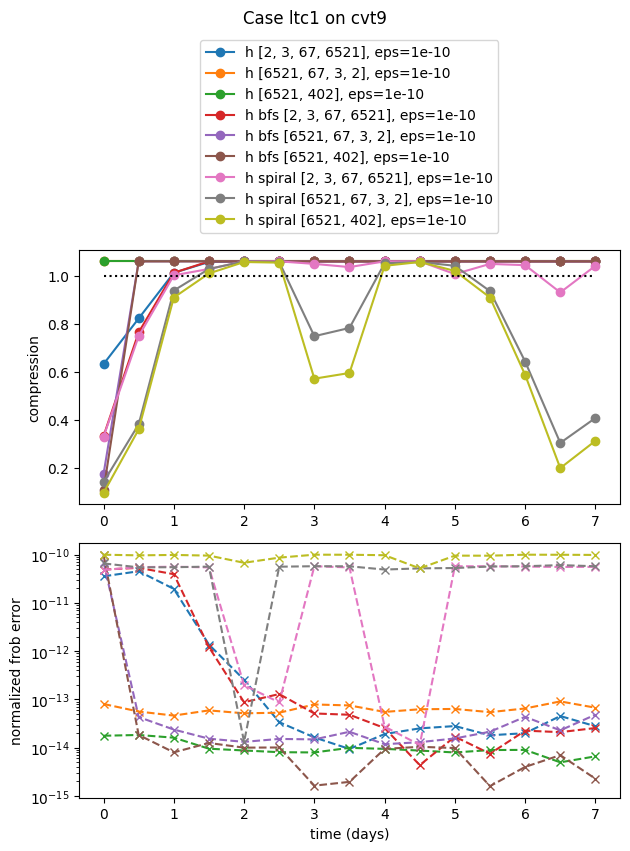

In [10]:
do_patches = 0
eps_h = 1e-10

data = [# default, no sorting or special folding
        {'var': hh_cell, 
         'shape': full_shape_cell, 
         'eps': eps_h, 
         'name': 'h ' + str(full_shape_cell)},
        # no ordering, reversed shape
        {'var': hh_cell, 
         'shape': reversed_full_shape_cell, 
         'eps': eps_h, 
         'name': 'h ' + str(reversed_full_shape_cell)},
        # no ordering, mat shape
        {'var': hh_cell, 
         'shape': mat_shape_cell, 
         'eps': eps_h, 
         'name': 'h ' + str(mat_shape_cell)},
        # bfs ordering, no special folding
        {'var': hh_cell[:, bfs_inds_cell],
         'shape': full_shape_cell, 
         'eps': eps_h,
         'name': 'h bfs ' + str(full_shape_cell)},
        # bfs ordering, reversed shape
        {'var': hh_cell[:, bfs_inds_cell],
         'shape': reversed_full_shape_cell, 
         'eps': eps_h,
         'name': 'h bfs ' + str(reversed_full_shape_cell)},
        # bfs ordering, mat shape
        {'var': hh_cell[:, bfs_inds_cell],
         'shape': mat_shape_cell, 
         'eps': eps_h,
         'name': 'h bfs ' + str(mat_shape_cell)},
        # spiral ordering, no special folding
        {'var': hh_cell[:, spiral_inds_cell],
         'shape': full_shape_cell,
         'eps': eps_h,
         'name': 'h spiral ' + str(full_shape_cell)},
        # spiral ordering, with larger first modes
        {'var': hh_cell[:, spiral_inds_cell],
         'shape': reversed_full_shape_cell,
         'eps': eps_h,
         'name': 'h spiral ' + str(reversed_full_shape_cell)},
         # spiral ordering, with large first mode, flattened tail modes
        {'var': hh_cell[:, spiral_inds_cell],
         'shape': mat_shape_cell,
         'eps': eps_h,
         'name': 'h spiral ' + str(mat_shape_cell)}]
if do_patches:
    # add all patch configs to data
    for patch_data in patches_data:
        data.append({'var': hh_cell[:, patch_data['sorted_inds']],
                     'shape': patch_data['shape'],
                     'eps': eps_h,
                     'name': 'h patch bfs ' + str(patch_data['shape'])})
    # END for
# END if

compression, err = get_compression_data(data)
make_eps_plot(data, compression, err,
              test_case,
              f'Case {test_case} on cvt{mesh_num}',
              f'{test_case}_{mesh_num}_{eps_h}.png')